In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from joblib import load
from tqdm import tqdm
import warnings

from sklearn.metrics import classification_report
warnings.filterwarnings("ignore")
import glob
import os
from collections import OrderedDict 
 
import numpy as np
import matplotlib.pyplot as plt  

import pandas as pd 


In [8]:
import yaml
from src.data.modules.LitData  import LitData
from src.layers.selfsupervised.lightcurve import LightCurveClassifier
DICT = {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
    }
def produce_report(path_1):
    path_args = glob.glob(f"{path_1}*args*")[0]
    #print(path_args)
    with open(path_args, 'r') as file:
        args = yaml.safe_load(file)
    #print('Initializing models') 
    from src.layers.selfsupervised.multimodal import ATAT
    model = ATAT(**args) 

    #print('Loading checkpoints')
    checkpoint_path_clip = glob.glob(
        f"{path_1}*my_best_checkpoint*"
    ) 
    #print(checkpoint_path_clip[-1])
    checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:2'))
    od_atat = OrderedDict() 
    for key in checkpoint_clip["state_dict"].keys(): 
            #print(key)
            if 'project' in key:
                continue
            if 'atat' in key:
                od_atat[key.replace("atat.", "")] = checkpoint_clip["state_dict"][key]

    model.load_state_dict(od_atat,strict=True)
    args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
    args['general']['use_sampler'] = False
    args['general']['batch_size'] = 128

    pl_datal = LitData(**args['general'])
    dataloader = pl_datal.test_dataloader() 
    target = None
    preds_out = None

    model.eval().to(device = 'cuda:2')  

    for b1 in tqdm(dataloader):

        #print(b1.keys())
        b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}

        lc_emb,tab_emb,mix_emb = model(**b1)  
    
        t = b1['labels']


        preds_out = (
            np.concatenate([preds_out, torch.argmax(mix_emb, axis=1).cpu().numpy()])
            if preds_out is not None
            else torch.argmax(mix_emb, axis=1).cpu().detach().numpy()
        )

        target = (
            np.concatenate([target, t.cpu().detach().numpy()])
            if target is not None
            else t.cpu().numpy()
        )
    results = preds_out
    classification = classification_report(target, results, target_names=list(DICT.keys()),digits = 4)
    print(classification)
    data_dict =  classification_report(target, results, target_names=list(DICT.keys()),digits = 4, output_dict=True)
    return data_dict

In [9]:
data_dict_1 = produce_report('/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC_MD/MM_BASELINE_/')
data_dict_2 = produce_report('/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC_MD/MM_bothmultiple48v2_/')

{'embedding_size': 128, 'embedding_size_sub': 256, 'num_heads': 4, 'num_encoders': 3, 'encoder_type': 'Linear', 'length_size': 6, 'list_time_to_eval': None}
using set test total of idx : 50501,                 use_lightcurves True, use_metadata True, use_features False,                     use MTA False
list_time_to_eval:  [16, 32, 64, 128, 256, 512, 1024, 2048]
using set_Type test
NOT USING SAMPLER


100%|██████████| 395/395 [00:22<00:00, 17.47it/s]


                precision    recall  f1-score   support

           AGN     0.7909    0.7682    0.7794      3935
           QSO     0.8139    0.8313    0.8225      4108
            EA     0.7352    0.7597    0.7472      4352
           YSO     0.7927    0.7402    0.7655      3295
          SNIa     0.6432    0.4037    0.4960      2175
       CV/Nova     0.7024    0.7490    0.7249      1944
          RRLc     0.7138    0.7000    0.7068      4243
         RSCVn     0.7084    0.7474    0.7274      3124
        Blazar     0.7601    0.7455    0.7527      1709
          SNII     0.3417    0.2885    0.3128      1040
         EB/EW     0.7014    0.6607    0.6804      4615
           LPV     0.9432    0.9117    0.9272      4135
           CEP     0.7430    0.6568    0.6972      3508
         RRLab     0.7437    0.6968    0.7195      4423
Periodic-Other     0.3039    0.4920    0.3757       874
          DSCT     0.4905    0.5420    0.5150      2059
         SNIbc     0.1627    0.2211    0.1874  

100%|██████████| 395/395 [00:22<00:00, 17.37it/s]

                precision    recall  f1-score   support

           AGN     0.8016    0.7720    0.7865      3935
           QSO     0.8245    0.8096    0.8170      4108
            EA     0.7806    0.7858    0.7832      4352
           YSO     0.7705    0.7806    0.7755      3295
          SNIa     0.6538    0.4437    0.5286      2175
       CV/Nova     0.7028    0.7701    0.7349      1944
          RRLc     0.7937    0.7045    0.7464      4243
         RSCVn     0.7088    0.7705    0.7383      3124
        Blazar     0.7284    0.7894    0.7577      1709
          SNII     0.3574    0.2856    0.3175      1040
         EB/EW     0.7501    0.6938    0.7208      4615
           LPV     0.9359    0.9219    0.9288      4135
           CEP     0.7601    0.6790    0.7173      3508
         RRLab     0.7830    0.7165    0.7483      4423
Periodic-Other     0.3178    0.4931    0.3865       874
          DSCT     0.5238    0.6513    0.5806      2059
         SNIbc     0.1778    0.2940    0.2216  

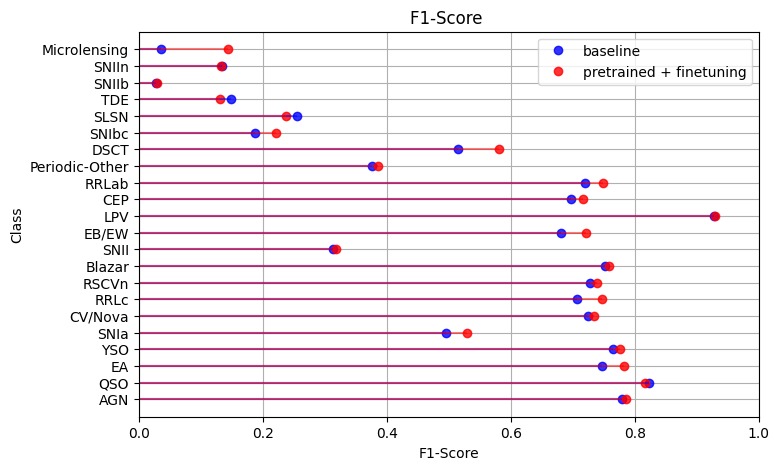

In [12]:
f1_baseline = []
f1_finetune = []

fig,ax = plt.subplots(1,1,figsize = (8,5))
for key,value in data_dict_1.items():
    if key in DICT.keys():
        #print(key,value)
        f1_baseline.append(value['f1-score'])
df_1 = pd.DataFrame({'group':DICT.keys(), 'values':f1_baseline })
ordered_df_1 = df_1#.sort_values(by='values')
my_range_1=range(1,len(df_1.index)+1)
 

for key,value in data_dict_2.items():
    if key in DICT.keys():
        #print(key,value)
        f1_finetune.append(value['f1-score'])
df_2 = pd.DataFrame({'group':DICT.keys(), 'values':f1_finetune})
ordered_df_2 = df_2#.sort_values(by='values')
my_range_2=range(1,len(df_2.index)+1)
plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
plt.plot(ordered_df_2['values'].values, my_range_2, "o", alpha = 0.8,color='red')

plt.legend(['baseline','pretrained + finetuning'])
 
# The horizontal plot is made using the hline function
plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)
 
# The horizontal plot is made using the hline function
plt.hlines(y=my_range_2, xmin=0, xmax=ordered_df_2['values'], color='red', alpha = 0.5)



# Add titles and axis names
plt.yticks(my_range_1, ordered_df_1['group'])
plt.title("F1-Score ", loc='center')

plt.xlabel('F1-Score')
plt.ylabel('Class')
plt.xlim(0,1)
#plt.xticks(np.arange(0,1,50), ordered_df_1['group'])

plt.grid('on', )
# Show the plot
plt.show()

In [13]:
transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}
stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}
periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}